In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("TensorFlow version:", tf.__version__)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

sns.set_style("whitegrid")

np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.20.0
Pandas version: 2.2.2
NumPy version: 2.0.2


In [ ]:
df = pd.read_csv("/content/Breast Cancer Wisconsin (Diagnostic).data")

In [ ]:
df.head()

,842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,...,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
0,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
4,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


In [ ]:
df.tail()

,842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,...,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
563,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
564,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
565,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
566,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
567,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [ ]:
df.shape

(568, 32)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568 entries, 0 to 567
Data columns (total 32 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   842302    568 non-null    int64  
 1   M         568 non-null    object 
 2   17.99     568 non-null    float64
 3   10.38     568 non-null    float64
 4   122.8     568 non-null    float64
 5   1001      568 non-null    float64
 6   0.1184    568 non-null    float64
 7   0.2776    568 non-null    float64
 8   0.3001    568 non-null    float64
 9   0.1471    568 non-null    float64
 10  0.2419    568 non-null    float64
 11  0.07871   568 non-null    float64
 12  1.095     568 non-null    float64
 13  0.9053    568 non-null    float64
 14  8.589     568 non-null    float64
 15  153.4     568 non-null    float64
 16  0.006399  568 non-null    float64
 17  0.04904   568 non-null    float64
 18  0.05373   568 non-null    float64
 19  0.01587   568 non-null    float64
 20  0.03003   568 non-null    float6

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
842302,0
M,0
17.99,0
10.38,0
122.8,0
1001,0
0.1184,0
0.2776,0
0.3001,0
0.1471,0


In [ ]:
(df.isnull().sum() / len(df)) * 100

,0
842302,0.0
M,0.0
17.99,0.0
10.38,0.0
122.8,0.0
1001,0.0
0.1184,0.0
0.2776,0.0
0.3001,0.0
0.1471,0.0


In [ ]:
df.describe()

,842302,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,0.2419,...,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
count,5.680000e+02,568.000000,568.000000,568.000000,568.000000,568.000000,568.000000,568.000000,568.000000,568.000000,...,568.00000,568.000000,568.000000,568.000000,568.000000,568.000000,568.000000,568.000000,568.000000,568.000000
mean,3.042382e+07,14.120491,19.305335,91.914754,654.279754,0.096321,0.104036,0.088427,0.048746,0.181055,...,16.25315,25.691919,107.125053,878.578873,0.132316,0.253541,0.271414,0.114341,0.289776,0.083884
std,1.251246e+08,3.523416,4.288506,24.285848,351.923751,0.014046,0.052355,0.079294,0.038617,0.027319,...,4.82232,6.141662,33.474687,567.846267,0.022818,0.156523,0.207989,0.065484,0.061508,0.018017
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.93000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692225e+05,11.697500,16.177500,75.135000,420.175000,0.086290,0.064815,0.029540,0.020310,0.161900,...,13.01000,21.095000,84.102500,514.975000,0.116600,0.146900,0.114475,0.064730,0.250350,0.071412
50%,9.061570e+05,13.355000,18.855000,86.210000,548.750000,0.095865,0.092525,0.061400,0.033455,0.179200,...,14.96500,25.425000,97.655000,685.550000,0.131300,0.211850,0.226550,0.099840,0.282050,0.080015
75%,8.825022e+06,15.780000,21.802500,103.875000,782.625000,0.105300,0.130400,0.129650,0.073730,0.195625,...,18.76750,29.757500,125.175000,1073.500000,0.146000,0.337600,0.381400,0.161325,0.317675,0.092065
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.04000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


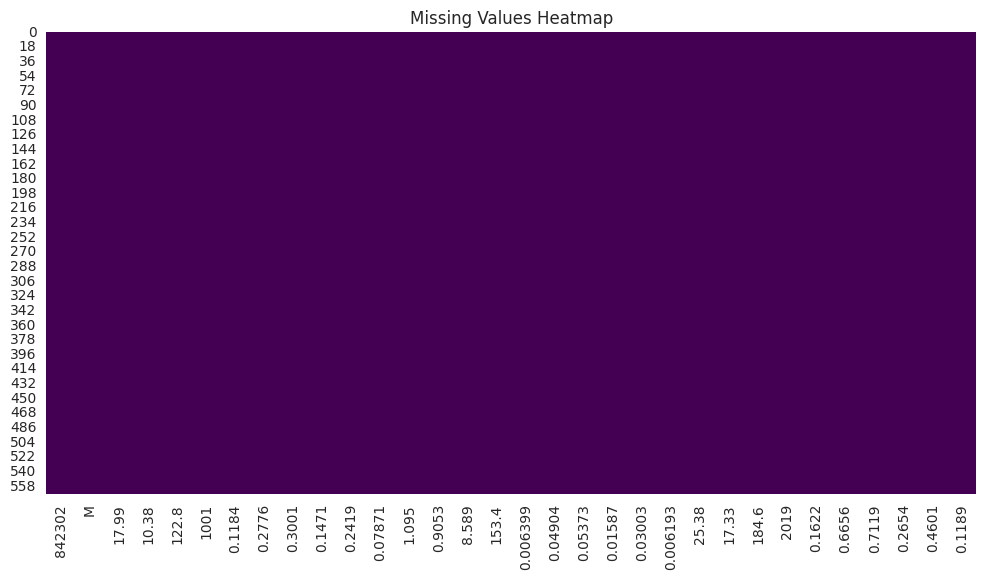

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title("Missing Values Heatmap")

plt.show()

In [ ]:
df.rename(columns={'M': 'diagnosis'}, inplace=True)
print(df["diagnosis"].value_counts())

diagnosis
B    357
M    211
Name: count, dtype: int64


In [ ]:
df["target"] = df["diagnosis"].map({
    "M": 0,
    "B": 1
})

print(df["target"].value_counts())

target
1    357
0    211
Name: count, dtype: int64


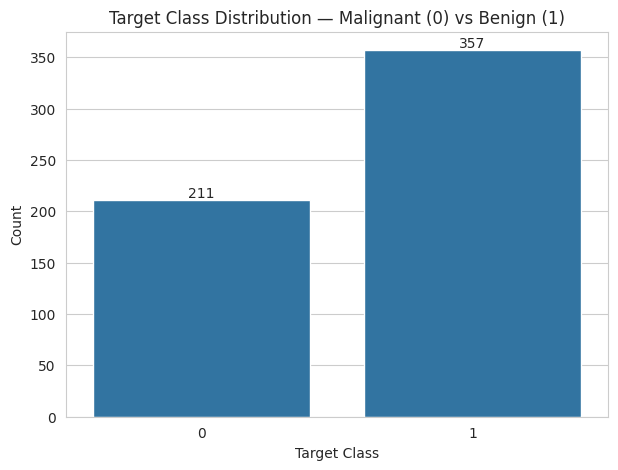

In [ ]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    x=df["target"]
)

plt.title(
    "Target Class Distribution — Malignant (0) vs Benign (1)"
)

plt.xlabel("Target Class")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [ ]:
feature_columns = [
    col for col in df.columns
    if col not in ["id", "diagnosis", "target"]
]

X = df[feature_columns]
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (568, 31)
y shape: (568,)


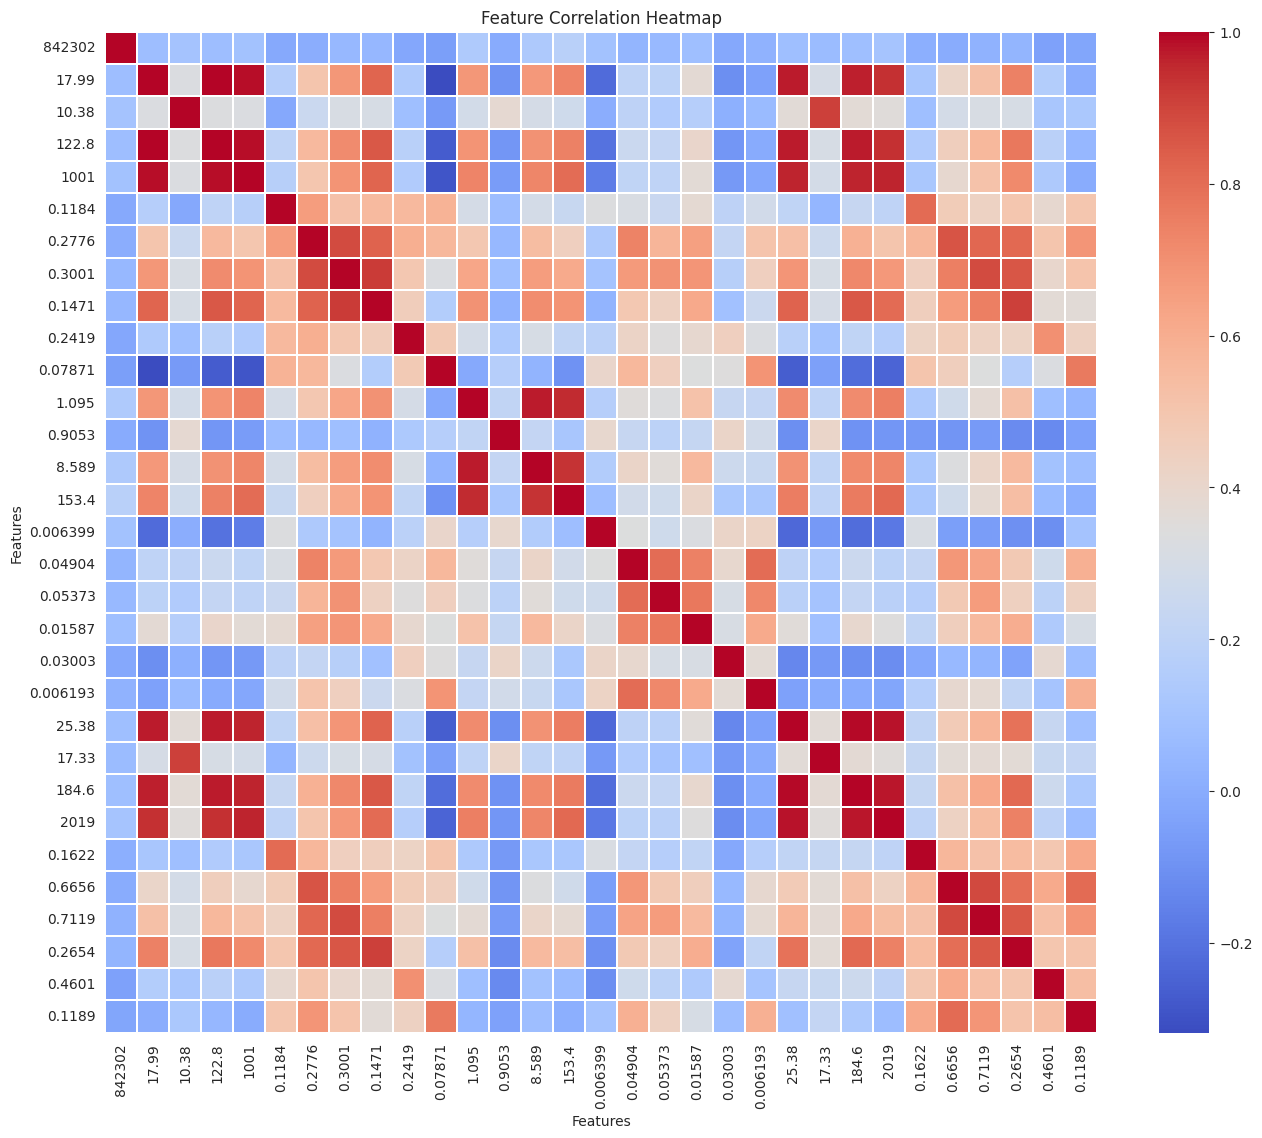

In [ ]:
correlation_matrix = X.corr()

plt.figure(figsize=(16, 13))

sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap="coolwarm",
    linewidths=0.3
)

plt.title("Feature Correlation Heatmap")
plt.xlabel("Features")
plt.ylabel("Features")

plt.show()

In [ ]:
corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)

print(corr_pairs.head(10))

17.99  122.8    0.997876
25.38  184.6    0.993814
17.99  1001     0.987344
122.8  1001     0.986548
25.38  2019     0.983919
184.6  2019     0.977475
1.095  8.589    0.972555
122.8  184.6    0.971157
17.99  25.38    0.969964
122.8  25.38    0.969675
dtype: float64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (454, 31)
X_test : (114, 31)
y_train: (454,)
y_test : (114,)


In [ ]:
print("Overall class distribution:")
print(y.value_counts(normalize=True))

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Overall class distribution:
target
1    0.628521
0    0.371479
Name: proportion, dtype: float64

Training class distribution:
target
1    0.627753
0    0.372247
Name: proportion, dtype: float64

Testing class distribution:
target
1    0.631579
0    0.368421
Name: proportion, dtype: float64


In [ ]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)

X_test_sc = scaler.transform(X_test)

print("Scaled training shape:", X_train_sc.shape)
print("Scaled testing shape:", X_test_sc.shape)

Scaled training shape: (454, 31)
Scaled testing shape: (114, 31)


In [ ]:
print(
    "Training feature means:\n",
    X_train_sc.mean(axis=0).round(2)
)

print(
    "\nTraining feature standard deviations:\n",
    X_train_sc.std(axis=0).round(2)
)

Training feature means:
 [ 0.  0. -0. -0.  0. -0. -0. -0. -0.  0.  0.  0.  0.  0. -0.  0.  0. -0.
  0. -0. -0.  0.  0. -0.  0. -0.  0.  0.  0. -0.  0.]

Training feature standard deviations:
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
model_slp = keras.Sequential([
    keras.layers.Dense(
        1,
        activation="sigmoid",
        input_shape=(30,)
    )
])

model_slp.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_slp.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model_slp = keras.Sequential([
    keras.layers.Dense(
        1,
        activation="sigmoid",
        input_shape=(X_train_sc.shape[1],)
    )
])

model_slp.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_slp = model_slp.fit(
    X_train_sc,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3088 - loss: 1.2069 - val_accuracy: 0.2391 - val_loss: 1.2124
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3407 - loss: 1.0862 - val_accuracy: 0.3261 - val_loss: 1.0817
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3848 - loss: 0.9758 - val_accuracy: 0.3478 - val_loss: 0.9632
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4412 - loss: 0.8764 - val_accuracy: 0.3913 - val_loss: 0.8579
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4975 - loss: 0.7884 - val_accuracy: 0.4565 - val_loss: 0.7658
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5539 - loss: 0.7117 - val_accuracy: 0.5217 - val_loss: 0.6866
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6176 - loss: 0.6456 - val_accuracy: 0.5870 - val_loss: 0.6193
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6863 - loss: 0.5890 - val_accuracy: 0.6304 - val_loss: 0.

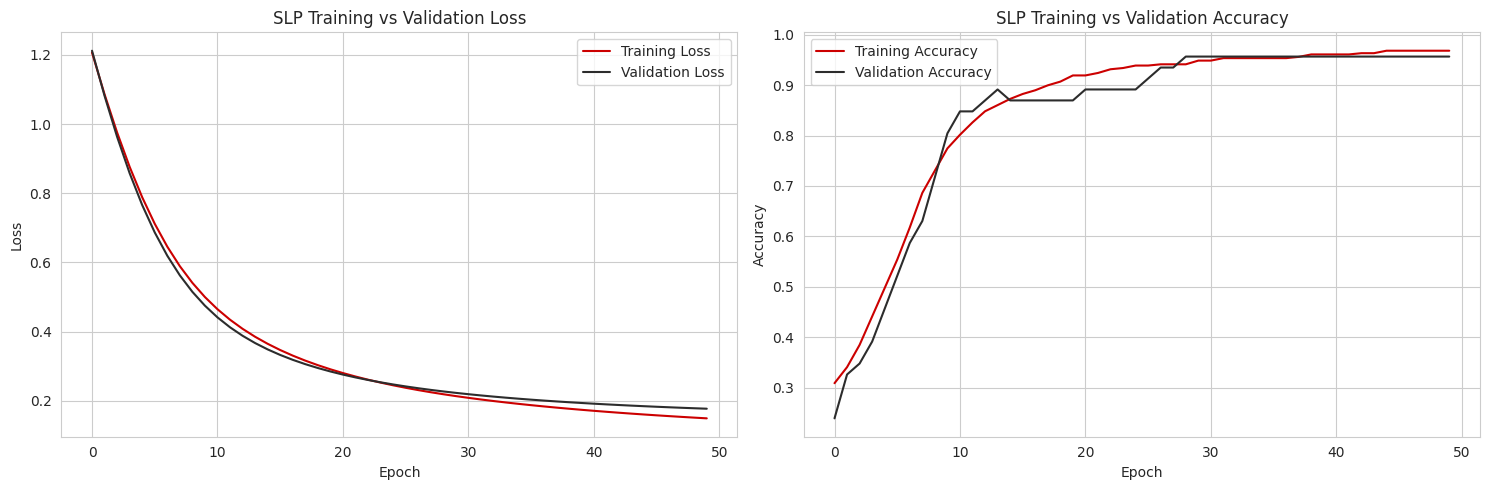

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(
    history_slp.history["loss"],
    label="Training Loss",
    color="#CC0000"
)

axes[0].plot(
    history_slp.history["val_loss"],
    label="Validation Loss",
    color="#2C2C2C"
)

axes[0].set_title("SLP Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy
axes[1].plot(
    history_slp.history["accuracy"],
    label="Training Accuracy",
    color="#CC0000"
)

axes[1].plot(
    history_slp.history["val_accuracy"],
    label="Validation Accuracy",
    color="#2C2C2C"
)

axes[1].set_title("SLP Training vs Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
slp_loss, slp_acc = model_slp.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

print("SLP Test Accuracy:", slp_acc)

SLP Test Accuracy: 0.9298245906829834


In [ ]:
y_prob_slp = model_slp.predict(X_test_sc, verbose=0)

y_pred_slp = (
    y_prob_slp > 0.5
).astype(int).ravel()

print(classification_report(
    y_test,
    y_pred_slp,
    target_names=["Malignant", "Benign"]
))

              precision    recall  f1-score   support

   Malignant       0.85      0.98      0.91        42
      Benign       0.98      0.90      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.94      0.93       114
weighted avg       0.94      0.93      0.93       114



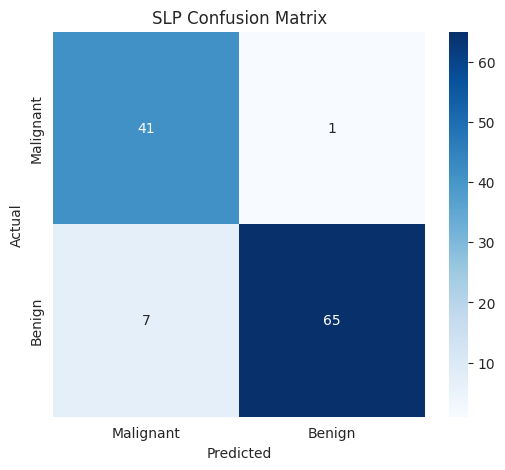

In [ ]:
cm_slp = confusion_matrix(
    y_test,
    y_pred_slp
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_slp,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.title("SLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
slp_precision = precision_score(
    y_test,
    y_pred_slp
)

slp_recall = recall_score(
    y_test,
    y_pred_slp
)

slp_f1 = f1_score(
    y_test,
    y_pred_slp
)

print("Accuracy :", slp_acc)
print("Precision:", slp_precision)
print("Recall   :", slp_recall)
print("F1 Score :", slp_f1)

Accuracy : 0.9298245906829834
Precision: 0.9848484848484849
Recall   : 0.9027777777777778
F1 Score : 0.9420289855072463


In [ ]:
model_mlp = keras.Sequential([
    keras.layers.Dense(
        64,
        activation="relu",
        input_shape=(30,)
    ),

    keras.layers.Dense(
        32,
        activation="relu"
    ),

    keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

model_mlp.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
params_layer1 = (30 * 64) + 64
params_layer2 = (64 * 32) + 32
params_output = (32 * 1) + 1

total_params = (
    params_layer1 +
    params_layer2 +
    params_output
)

print("Layer 1 parameters:", params_layer1)
print("Layer 2 parameters:", params_layer2)
print("Output parameters:", params_output)
print("Total parameters:", total_params)

Layer 1 parameters: 1984
Layer 2 parameters: 2080
Output parameters: 33
Total parameters: 4097


In [ ]:
model_mlp = keras.Sequential([
    keras.layers.Dense(
        64,
        activation="relu",
        input_shape=(X_train_sc.shape[1],)
    ),

    keras.layers.Dense(
        32,
        activation="relu"
    ),

    keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

model_mlp.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_mlp = model_mlp.fit(
    X_train_sc,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8358 - loss: 0.5258 - val_accuracy: 0.9565 - val_loss: 0.3591
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9510 - loss: 0.3316 - val_accuracy: 0.9783 - val_loss: 0.2358
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9583 - loss: 0.2107 - val_accuracy: 0.9783 - val_loss: 0.1645
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9632 - loss: 0.1439 - val_accuracy: 0.9783 - val_loss: 0.1342
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9706 - loss: 0.1103 - val_accuracy: 0.9783 - val_loss: 0.1190
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9730 - loss: 0.0908 - val_accuracy: 0.9783 - val_loss: 0.1102
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9804 - loss: 0.0782 - val_accuracy: 0.9783 - val_loss: 0.1060
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9804 - loss: 0.0695 - val_accuracy: 0.9783 - val_loss: 0

In [ ]:
def create_activation_model(activation):
    model = keras.Sequential([
        keras.layers.Dense(
            64,
            activation=activation,
            input_shape=(30,)
        ),

        keras.layers.Dense(
            32,
            activation=activation
        ),

        keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
def create_activation_model(activation):
    model = keras.Sequential([
        keras.layers.Dense(
            64,
            activation=activation,
            input_shape=(X_train_sc.shape[1],) # Dynamically set input shape
        ),

        keras.layers.Dense(
            32,
            activation=activation
        ),

        keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

model_relu = create_activation_model("relu")

history_relu = model_relu.fit(
    X_train_sc,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7402 - loss: 0.5914 - val_accuracy: 0.8696 - val_loss: 0.4259
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9314 - loss: 0.3234 - val_accuracy: 0.8913 - val_loss: 0.2717
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9510 - loss: 0.2108 - val_accuracy: 0.9130 - val_loss: 0.2058
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9534 - loss: 0.1560 - val_accuracy: 0.9348 - val_loss: 0.1720
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9657 - loss: 0.1240 - val_accuracy: 0.9783 - val_loss: 0.1530
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9730 - loss: 0.1034 - val_accuracy: 0.9783 - val_loss: 0.1423
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9779 - loss: 0.0889 - val_accuracy: 0.9783 - val_loss: 0.1363
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9804 - loss: 0.0779 - val_accuracy: 0.9783 - val_loss: 

In [ ]:
model_tanh = create_activation_model("tanh")

history_tanh = model_tanh.fit(
    X_train_sc,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8995 - loss: 0.3391 - val_accuracy: 0.9783 - val_loss: 0.1922
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9559 - loss: 0.1414 - val_accuracy: 0.9783 - val_loss: 0.1460
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9681 - loss: 0.0959 - val_accuracy: 0.9783 - val_loss: 0.1368
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9706 - loss: 0.0774 - val_accuracy: 0.9783 - val_loss: 0.1354
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9804 - loss: 0.0671 - val_accuracy: 0.9783 - val_loss: 0.1368
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9853 - loss: 0.0604 - val_accuracy: 0.9783 - val_loss: 0.1387
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9877 - loss: 0.0554 - val_accuracy: 0.9783 - val_loss: 0.1407
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9877 - loss: 0.0515 - val_accuracy: 0.9783 - val_loss: 

In [ ]:
model_sigmoid = create_activation_model("sigmoid")

history_sigmoid = model_sigmoid.fit(
    X_train_sc,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.6397 - loss: 0.6439 - val_accuracy: 0.5217 - val_loss: 0.6643
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6397 - loss: 0.5775 - val_accuracy: 0.5217 - val_loss: 0.5961
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7132 - loss: 0.5166 - val_accuracy: 0.8261 - val_loss: 0.5185
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8407 - loss: 0.4514 - val_accuracy: 0.8913 - val_loss: 0.4408
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9167 - loss: 0.3837 - val_accuracy: 0.8913 - val_loss: 0.3691
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9338 - loss: 0.3208 - val_accuracy: 0.9130 - val_loss: 0.3095
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9387 - loss: 0.2682 - val_accuracy: 0.9130 - val_loss: 0.2644
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9412 - loss: 0.2269 - val_accuracy: 0.

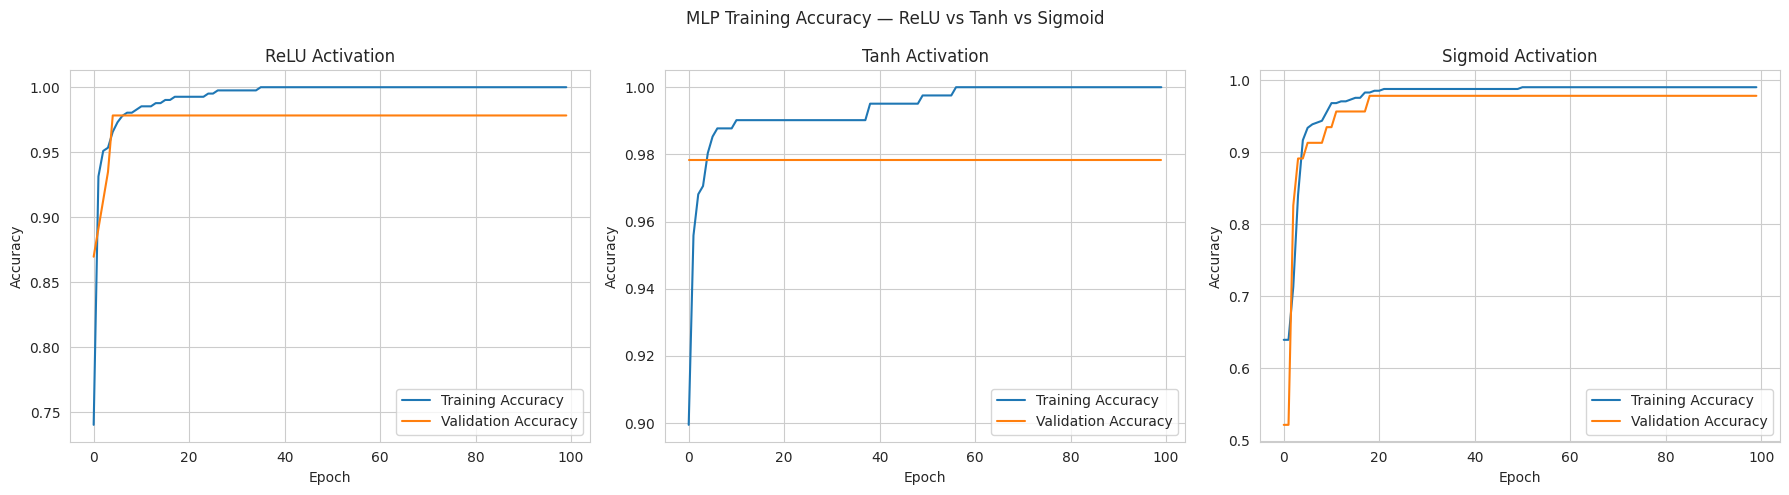

In [ ]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

activation_histories = [
    ("ReLU", history_relu),
    ("Tanh", history_tanh),
    ("Sigmoid", history_sigmoid)
]

for ax, (name, history) in zip(
    axes,
    activation_histories
):

    ax.plot(
        history.history["accuracy"],
        label="Training Accuracy"
    )

    ax.plot(
        history.history["val_accuracy"],
        label="Validation Accuracy"
    )

    ax.set_title(f"{name} Activation")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()

plt.suptitle(
    "MLP Training Accuracy — ReLU vs Tanh vs Sigmoid"
)

plt.tight_layout()
plt.show()

In [ ]:
activation_results = {
    "ReLU": history_relu.history["val_accuracy"][-1],
    "Tanh": history_tanh.history["val_accuracy"][-1],
    "Sigmoid": history_sigmoid.history["val_accuracy"][-1]
}

print(pd.Series(activation_results))

ReLU       0.978261
Tanh       0.978261
Sigmoid    0.978261
dtype: float64


In [ ]:
best_activation_validation = {
    "ReLU": max(history_relu.history["val_accuracy"]),
    "Tanh": max(history_tanh.history["val_accuracy"]),
    "Sigmoid": max(history_sigmoid.history["val_accuracy"])
}

print(
    pd.Series(best_activation_validation)
    .sort_values(ascending=False)
)

ReLU       0.978261
Tanh       0.978261
Sigmoid    0.978261
dtype: float64


In [ ]:
activation_models = {
    "ReLU": model_relu,
    "Tanh": model_tanh,
    "Sigmoid": model_sigmoid
}

activation_test_results = {}

for name, model in activation_models.items():

    loss, accuracy = model.evaluate(
        X_test_sc,
        y_test,
        verbose=0
    )

    activation_test_results[name] = accuracy

    print(f"{name} Test Accuracy: {accuracy:.4f}")

ReLU Test Accuracy: 0.9649
Tanh Test Accuracy: 0.9561
Sigmoid Test Accuracy: 0.9649


In [ ]:
best_activation = max(
    activation_test_results,
    key=activation_test_results.get
)

print("Best activation:", best_activation)
print(
    "Best test accuracy:",
    activation_test_results[best_activation]
)

Best activation: ReLU
Best test accuracy: 0.9649122953414917


In [ ]:
best_mlp = activation_models[best_activation]

y_prob_best_mlp = best_mlp.predict(
    X_test_sc,
    verbose=0
)

y_pred_best_mlp = (
    y_prob_best_mlp > 0.5
).astype(int).ravel()

print(
    classification_report(
        y_test,
        y_pred_best_mlp,
        target_names=["Malignant", "Benign"]
    )
)

              precision    recall  f1-score   support

   Malignant       0.91      1.00      0.95        42
      Benign       1.00      0.94      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



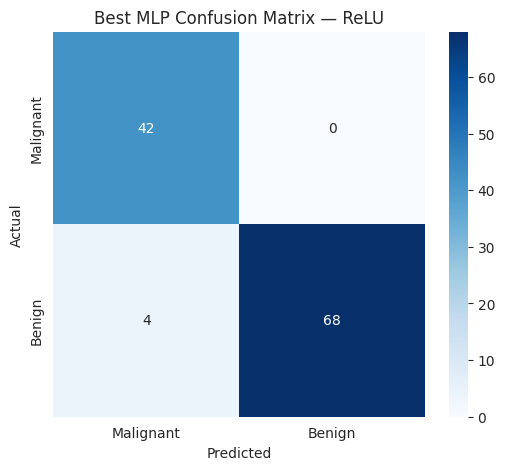

In [ ]:
cm_best_mlp = confusion_matrix(
    y_test,
    y_pred_best_mlp
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_best_mlp,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.title(f"Best MLP Confusion Matrix — {best_activation}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
def create_es_model():

    model = keras.Sequential([
        keras.layers.Dense(
            128,
            activation="relu",
            input_shape=(30,)
        ),

        keras.layers.Dense(
            64,
            activation="relu"
        ),

        keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
es = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
def create_es_model():

    model = keras.Sequential([
        keras.layers.Dense(
            128,
            activation="relu",
            input_shape=(X_train_sc.shape[1],) # Dynamically set input shape
        ),

        keras.layers.Dense(
            64,
            activation="relu"
        ),

        keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

model_es = create_es_model()

history_es = model_es.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9485 - loss: 0.3596 - val_accuracy: 0.9130 - val_loss: 0.2023
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9534 - loss: 0.1515 - val_accuracy: 0.9348 - val_loss: 0.1443
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9681 - loss: 0.0986 - val_accuracy: 0.9783 - val_loss: 0.1280
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9779 - loss: 0.0757 - val_accuracy: 0.9783 - val_loss: 0.1219
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9804 - loss: 0.0634 - val_accuracy: 0.9783 - val_loss: 0.1224
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9828 - loss: 0.0551 - val_accuracy: 0.9783 - val_loss: 0.1257
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9828 - loss: 0.0488 - val_accuracy: 0.9783 - val_loss: 0.1294
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9877 - loss: 0.0435 - val_accuracy: 0.9783 - val_loss: 0.

In [ ]:
model_es = create_es_model()

history_es = model_es.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8995 - loss: 0.4435 - val_accuracy: 0.9348 - val_loss: 0.2494
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9534 - loss: 0.1871 - val_accuracy: 0.9783 - val_loss: 0.1592
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9657 - loss: 0.1089 - val_accuracy: 0.9783 - val_loss: 0.1341
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9779 - loss: 0.0769 - val_accuracy: 0.9783 - val_loss: 0.1237
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9804 - loss: 0.0610 - val_accuracy: 0.9783 - val_loss: 0.1217
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9853 - loss: 0.0516 - val_accuracy: 0.9783 - val_loss: 0.1247
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9877 - loss: 0.0451 - val_accuracy: 0.9783 - val_loss: 0.1293
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9877 - loss: 0.0400 - val_accuracy: 0.9783 - val_loss: 0.

In [ ]:
stopping_epoch = len(
    history_es.history["loss"]
)

print(
    "Training stopped after",
    stopping_epoch,
    "epochs."
)

Training stopped after 20 epochs.


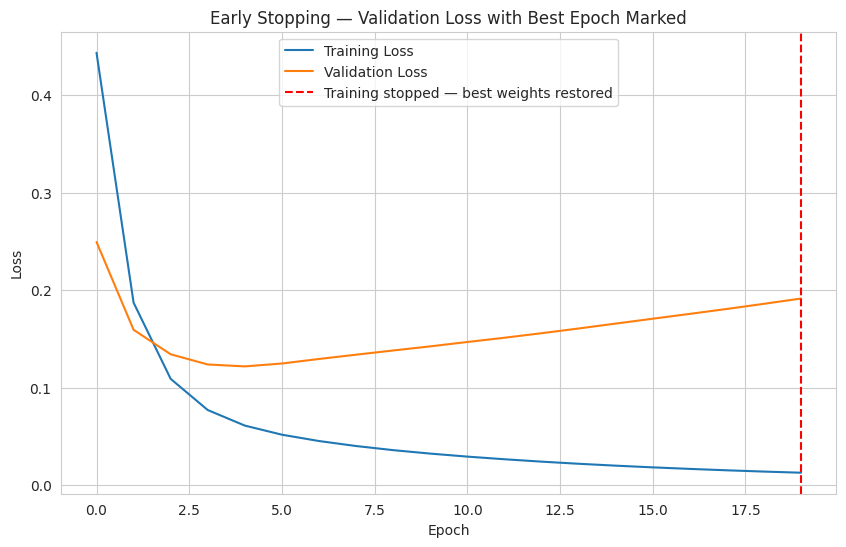

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_es.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_es.history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    stopping_epoch - 1,
    linestyle="--",
    color="red",
    label="Training stopped — best weights restored"
)

plt.title(
    "Early Stopping — Validation Loss with Best Epoch Marked"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
model_no_es = create_es_model()

history_no_es = model_no_es.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7966 - loss: 0.4978 - val_accuracy: 0.9348 - val_loss: 0.2661
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9485 - loss: 0.2105 - val_accuracy: 0.9348 - val_loss: 0.1763
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9583 - loss: 0.1229 - val_accuracy: 0.9348 - val_loss: 0.1517
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9730 - loss: 0.0873 - val_accuracy: 0.9783 - val_loss: 0.1380
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9804 - loss: 0.0693 - val_accuracy: 0.9783 - val_loss: 0.1335
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9804 - loss: 0.0587 - val_accuracy: 0.9783 - val_loss: 0.1362
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9877 - loss: 0.0511 - val_accuracy: 0.9783 - val_loss: 0.1406
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9877 - loss: 0.0454 - val_accuracy: 0.9783 - 

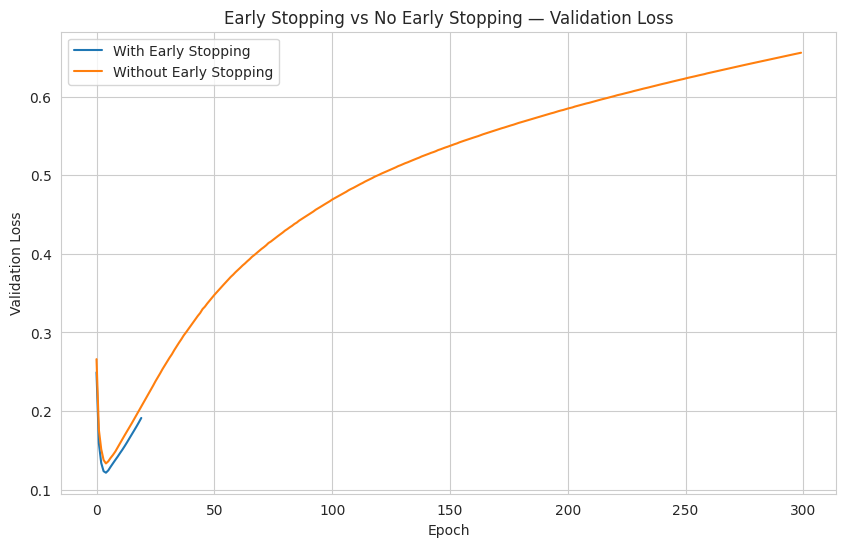

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_es.history["val_loss"],
    label="With Early Stopping"
)

plt.plot(
    history_no_es.history["val_loss"],
    label="Without Early Stopping"
)

plt.title(
    "Early Stopping vs No Early Stopping — Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.legend()

plt.show()

In [ ]:
best_es_val_loss = min(
    history_es.history["val_loss"]
)

best_no_es_val_loss = min(
    history_no_es.history["val_loss"]
)

print("Best Early Stopping validation loss:",
      best_es_val_loss)

print("Best No Early Stopping validation loss:",
      best_no_es_val_loss)

Best Early Stopping validation loss: 0.1217164695262909
Best No Early Stopping validation loss: 0.1335124373435974


In [ ]:
es_loss, es_acc = model_es.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

no_es_loss, no_es_acc = model_no_es.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

print("Early Stopping Accuracy:", es_acc)
print("No Early Stopping Accuracy:", no_es_acc)

Early Stopping Accuracy: 0.9824561476707458
No Early Stopping Accuracy: 0.9736841917037964


In [ ]:
def create_dropout_model(dropout_rate):

    model = keras.Sequential([

        keras.layers.Dense(
            128,
            activation="relu",
            input_shape=(X_train_sc.shape[1],) # Dynamically set input shape
        ),

        keras.layers.Dropout(dropout_rate),

        keras.layers.Dense(
            64,
            activation="relu"
        ),

        keras.layers.Dropout(dropout_rate),

        keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
model_drop = create_dropout_model(0.3)

es_drop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history_drop = model_drop.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_drop],
    verbose=1
)

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8529 - loss: 0.4453 - val_accuracy: 0.9565 - val_loss: 0.2275
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9461 - loss: 0.2220 - val_accuracy: 0.9565 - val_loss: 0.1508
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9583 - loss: 0.1440 - val_accuracy: 0.9783 - val_loss: 0.1335
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9706 - loss: 0.1044 - val_accuracy: 0.9783 - val_loss: 0.1271
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9706 - loss: 0.0876 - val_accuracy: 0.9783 - val_loss: 0.1228
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9779 - loss: 0.0822 - val_accuracy: 0.9783 - val_loss: 0.1231
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9706 - loss: 0.0738 - val_accuracy: 0.9783 - val_loss: 0.1217
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9779 - loss: 0.0624 - val_accuracy: 0.9783 - val_loss: 0

In [ ]:
model_drop_01 = create_dropout_model(0.1)

history_drop_01 = model_drop_01.fit(
    X_train_sc,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=20,
            restore_best_weights=True,
            verbose=1
        )
    ],
    verbose=1
)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8652 - loss: 0.4616 - val_accuracy: 0.9348 - val_loss: 0.2567
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9510 - loss: 0.2058 - val_accuracy: 0.9348 - val_loss: 0.1622
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9583 - loss: 0.1234 - val_accuracy: 0.9348 - val_loss: 0.1383
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9755 - loss: 0.0873 - val_accuracy: 0.9565 - val_loss: 0.1255
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9779 - loss: 0.0707 - val_accuracy: 0.9783 - val_loss: 0.1184
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9779 - loss: 0.0646 - val_accuracy: 0.9783 - val_loss: 0.1190
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9853 - loss: 0.0547 - val_accuracy: 0.9783 - val_loss: 0.1234
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9877 - loss: 0.0476 - val_accuracy: 0.9783 - 

In [ ]:
model_drop_05 = create_dropout_model(0.5)

history_drop_05 = model_drop_05.fit(
    X_train_sc,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=20,
            restore_best_weights=True,
            verbose=1
        )
    ],
    verbose=1
)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6005 - loss: 0.6884 - val_accuracy: 0.9348 - val_loss: 0.3787
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8725 - loss: 0.3798 - val_accuracy: 0.9348 - val_loss: 0.2319
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9265 - loss: 0.2379 - val_accuracy: 0.9348 - val_loss: 0.1798
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9338 - loss: 0.1927 - val_accuracy: 0.9348 - val_loss: 0.1567
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9583 - loss: 0.1381 - val_accuracy: 0.9565 - val_loss: 0.1434
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9657 - loss: 0.1335 - val_accuracy: 0.9783 - val_loss: 0.1354
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9657 - loss: 0.1101 - val_accuracy: 0.9783 - val_loss: 0.1307
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9583 - loss: 0.1153 - val_accuracy: 0.9783 - 

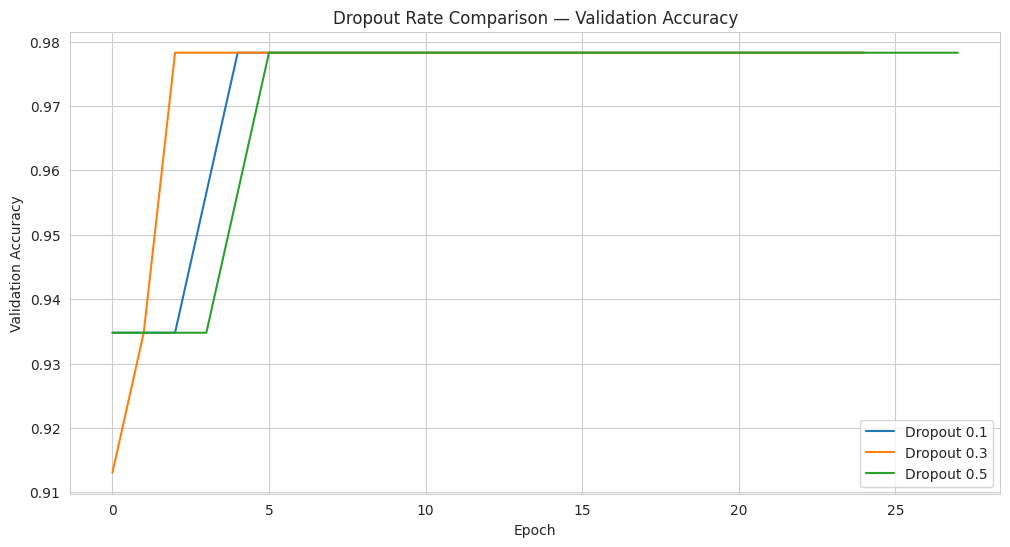

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    history_drop_01.history["val_accuracy"],
    label="Dropout 0.1"
)

plt.plot(
    history_drop.history["val_accuracy"],
    label="Dropout 0.3"
)

plt.plot(
    history_drop_05.history["val_accuracy"],
    label="Dropout 0.5"
)

plt.title(
    "Dropout Rate Comparison — Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.legend()

plt.show()

In [ ]:
dropout_models = {
    "Dropout 0.1": model_drop_01,
    "Dropout 0.3": model_drop,
    "Dropout 0.5": model_drop_05
}

dropout_validation_results = {
    "Dropout 0.1": max(history_drop_01.history["val_accuracy"]),
    "Dropout 0.3": max(history_drop.history["val_accuracy"]),
    "Dropout 0.5": max(history_drop_05.history["val_accuracy"])
}

best_dropout_name = max(
    dropout_validation_results,
    key=dropout_validation_results.get
)

best_dropout_model = dropout_models[
    best_dropout_name
]

print("Best Dropout Configuration:",
      best_dropout_name)

Best Dropout Configuration: Dropout 0.1


In [ ]:
drop_loss, drop_acc = best_dropout_model.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

print("Best Dropout Model Test Accuracy:", drop_acc)

Best Dropout Model Test Accuracy: 0.9824561476707458


In [ ]:
y_prob_best_dropout = best_dropout_model.predict(
    X_test_sc,
    verbose=0
)

y_pred_best_dropout = (
    y_prob_best_dropout > 0.5
).astype(int).ravel()

print(classification_report(
    y_test,
    y_pred_best_dropout,
    target_names=["Malignant", "Benign"]
))

              precision    recall  f1-score   support

   Malignant       0.95      1.00      0.98        42
      Benign       1.00      0.97      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.99      0.98       114
weighted avg       0.98      0.98      0.98       114



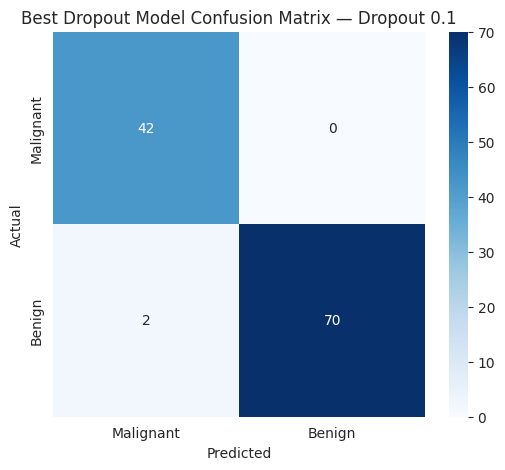

In [ ]:
cm_best_dropout = confusion_matrix(
    y_test,
    y_pred_best_dropout
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_best_dropout,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.title(f"Best Dropout Model Confusion Matrix — {best_dropout_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
drop_precision = precision_score(
    y_test,
    y_pred_best_dropout
)

drop_recall = recall_score(
    y_test,
    y_pred_best_dropout
)

drop_f1 = f1_score(
    y_test,
    y_pred_best_dropout
)

print("Accuracy :", drop_acc)
print("Precision:", drop_precision)
print("Recall   :", drop_recall)
print("F1 Score :", drop_f1)

Accuracy : 0.9824561476707458
Precision: 1.0
Recall   : 0.9722222222222222
F1 Score : 0.9859154929577465


In [ ]:
drop_loss, drop_acc = best_dropout_model.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

print(
    "Best Dropout Model:",
    best_dropout_name
)

print(
    "Test Accuracy:",
    drop_acc
)

Best Dropout Model: Dropout 0.1
Test Accuracy: 0.9824561476707458


In [ ]:
model_l2 = keras.Sequential([

    keras.layers.Dense(
        128,
        activation="relu",
        input_shape=(X_train_sc.shape[1],),
        kernel_regularizer=regularizers.l2(0.001)
    ),

    keras.layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),

    keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

model_l2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
es_l2 = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history_l2 = model_l2.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_l2],
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8039 - loss: 0.6149 - val_accuracy: 0.9348 - val_loss: 0.3700
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9485 - loss: 0.3160 - val_accuracy: 0.9348 - val_loss: 0.2892
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9534 - loss: 0.2422 - val_accuracy: 0.9783 - val_loss: 0.2669
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9804 - loss: 0.2104 - val_accuracy: 0.9783 - val_loss: 0.2507
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9828 - loss: 0.1923 - val_accuracy: 0.9783 - val_loss: 0.2426
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9828 - loss: 0.1806 - val_accuracy: 0.9783 - val_loss: 0.2403
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9828 - loss: 0.1715 - val_accuracy: 0.9783 - val_loss: 0.2399
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9877 - loss: 0.1637 - val_accuracy: 0.9783 - 

In [ ]:
model_l1 = keras.Sequential([

    keras.layers.Dense(
        128,
        activation="relu",
        input_shape=(X_train_sc.shape[1],), # Dynamically set input shape
        kernel_regularizer=regularizers.l1(0.001)
    ),

    keras.layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l1(0.001)
    ),

    keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

model_l1.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
es_l1 = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history_l1 = model_l1.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_l1],
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8064 - loss: 1.5917 - val_accuracy: 0.9348 - val_loss: 1.3322
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9730 - loss: 1.2534 - val_accuracy: 0.9348 - val_loss: 1.1857
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9730 - loss: 1.1217 - val_accuracy: 0.9783 - val_loss: 1.1110
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9804 - loss: 1.0390 - val_accuracy: 0.9783 - val_loss: 1.0469
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9853 - loss: 0.9691 - val_accuracy: 0.9783 - val_loss: 0.9868
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9853 - loss: 0.9049 - val_accuracy: 0.9783 - val_loss: 0.9299
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9853 - loss: 0.8441 - val_accuracy: 0.9783 - val_loss: 0.8754
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9853 - loss: 0.7862 - val_accuracy: 0.9783 - 

In [ ]:
model_l1l2 = keras.Sequential([

    keras.layers.Dense(
        128,
        activation="relu",
        input_shape=(X_train_sc.shape[1],),
        kernel_regularizer=regularizers.l1_l2(
            l1=0.0001,
            l2=0.001
        )
    ),

    keras.layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l1_l2(
            l1=0.0001,
            l2=0.001
        )
    ),

    keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

model_l1l2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
es_l1l2 = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history_l1l2 = model_l1l2.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_l1l2],
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8431 - loss: 0.7100 - val_accuracy: 0.9348 - val_loss: 0.4974
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9583 - loss: 0.4346 - val_accuracy: 0.9565 - val_loss: 0.4031
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9608 - loss: 0.3532 - val_accuracy: 0.9565 - val_loss: 0.3731
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9755 - loss: 0.3172 - val_accuracy: 0.9783 - val_loss: 0.3535
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9804 - loss: 0.2949 - val_accuracy: 0.9783 - val_loss: 0.3412
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9853 - loss: 0.2785 - val_accuracy: 0.9783 - val_loss: 0.3342
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9853 - loss: 0.2647 - val_accuracy: 0.9783 - val_loss: 0.3288
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9853 - loss: 0.2526 - val_accuracy: 0.9783 -

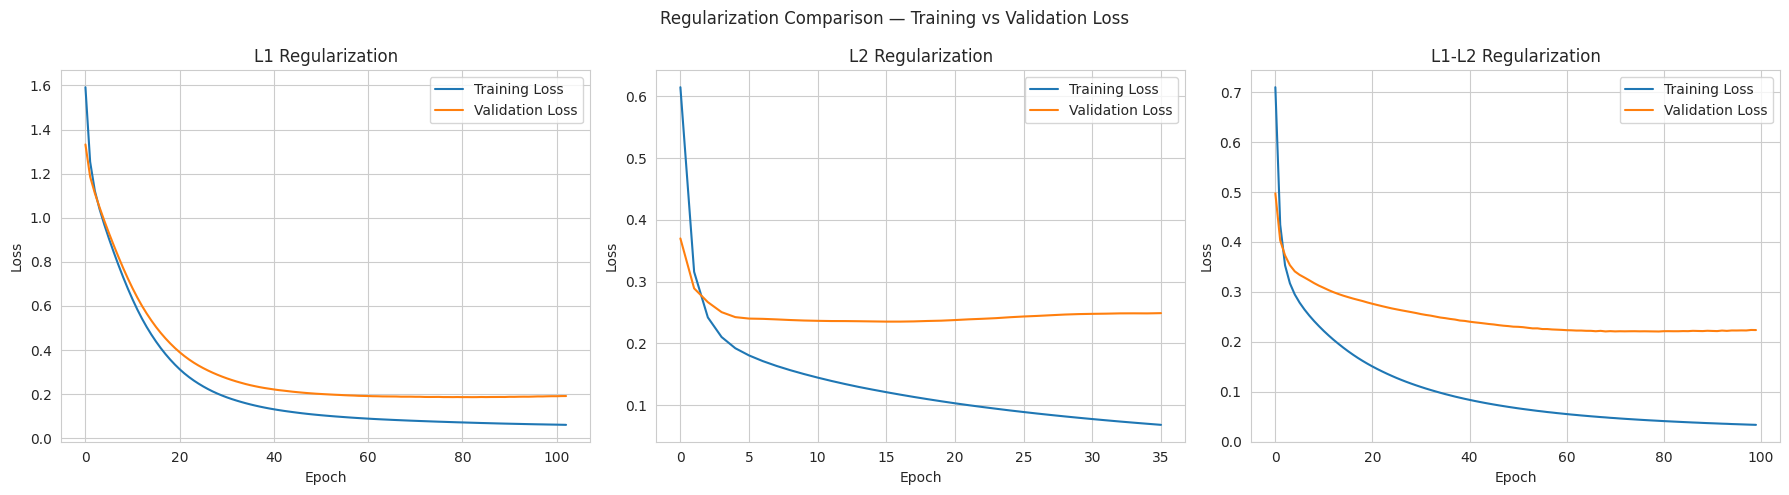

In [ ]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

regularization_histories = [
    ("L1", history_l1),
    ("L2", history_l2),
    ("L1-L2", history_l1l2)
]

for ax, (name, history) in zip(
    axes,
    regularization_histories
):

    ax.plot(
        history.history["loss"],
        label="Training Loss"
    )

    ax.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    ax.set_title(f"{name} Regularization")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

plt.suptitle(
    "Regularization Comparison — Training vs Validation Loss"
)

plt.tight_layout()
plt.show()

In [ ]:
regularized_models = {
    "L1": model_l1,
    "L2": model_l2,
    "L1-L2": model_l1l2
}

regularized_results = {}

for name, model in regularized_models.items():

    loss, accuracy = model.evaluate(
        X_test_sc,
        y_test,
        verbose=0
    )

    regularized_results[name] = accuracy

    print(
        f"{name} Test Accuracy: {accuracy:.4f}"
    )

L1 Test Accuracy: 0.9649
L2 Test Accuracy: 0.9649
L1-L2 Test Accuracy: 0.9649


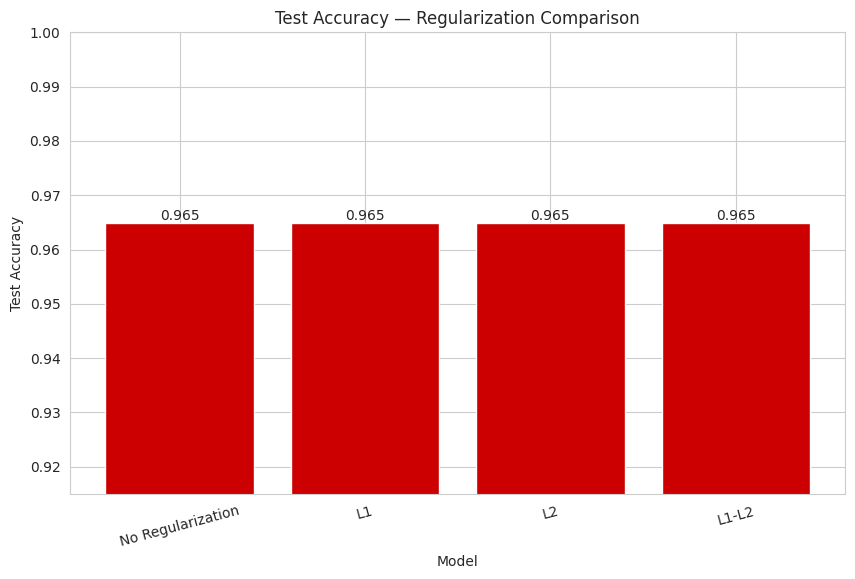

In [ ]:
no_reg_accuracy = activation_test_results[
    best_activation
]

comparison_accuracy = {
    "No Regularization": no_reg_accuracy,
    "L1": regularized_results["L1"],
    "L2": regularized_results["L2"],
    "L1-L2": regularized_results["L1-L2"]
}

plt.figure(figsize=(10, 6))

bars = plt.bar(
    comparison_accuracy.keys(),
    comparison_accuracy.values(),
    color="#CC0000"
)

plt.title(
    "Test Accuracy — Regularization Comparison"
)

plt.xlabel("Model")
plt.ylabel("Test Accuracy")

plt.ylim(
    max(0, min(comparison_accuracy.values()) - 0.05),
    1.0
)

plt.xticks(rotation=15)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom"
    )

plt.show()

In [ ]:
model_final = keras.Sequential([

    keras.layers.Dense(
        128,
        activation="relu",
        input_shape=(30,),
        kernel_regularizer=regularizers.l2(0.001)
    ),

    keras.layers.Dropout(0.3),

    keras.layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),

    keras.layers.Dropout(0.3),

    keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

model_final.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_final.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_65 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_final = keras.Sequential([

    keras.layers.Dense(
        128,
        activation="relu",
        input_shape=(X_train_sc.shape[1],),
        kernel_regularizer=regularizers.l2(0.001)
    ),

    keras.layers.Dropout(0.3),

    keras.layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),

    keras.layers.Dropout(0.3),

    keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

model_final.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

es_final = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history_final = model_final.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_final],
    verbose=1
)

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7451 - loss: 0.6773 - val_accuracy: 0.9348 - val_loss: 0.4301
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9338 - loss: 0.3729 - val_accuracy: 0.9565 - val_loss: 0.3133
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9559 - loss: 0.2843 - val_accuracy: 0.9783 - val_loss: 0.2826
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9608 - loss: 0.2460 - val_accuracy: 0.9783 - val_loss: 0.2717
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9730 - loss: 0.2187 - val_accuracy: 0.9783 - val_loss: 0.2653
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9755 - loss: 0.2138 - val_accuracy: 0.9783 - val_loss: 0.2620
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9804 - loss: 0.1927 - val_accuracy: 0.9783 - val_loss: 0.2623
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9902 - loss: 0.1827 - val_accuracy: 0.9783 - val_loss:

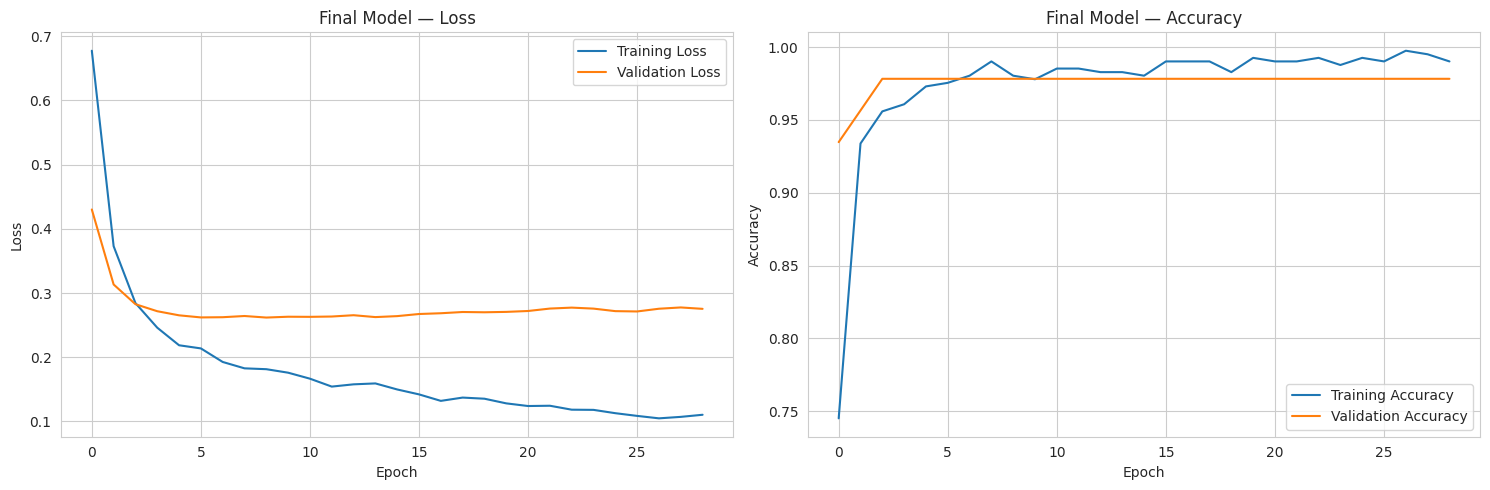

In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

axes[0].plot(
    history_final.history["loss"],
    label="Training Loss"
)

axes[0].plot(
    history_final.history["val_loss"],
    label="Validation Loss"
)

axes[0].set_title(
    "Final Model — Loss"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(
    history_final.history["accuracy"],
    label="Training Accuracy"
)

axes[1].plot(
    history_final.history["val_accuracy"],
    label="Validation Accuracy"
)

axes[1].set_title(
    "Final Model — Accuracy"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
y_prob_final = model_final.predict(
    X_test_sc,
    verbose=0
).ravel()

y_pred_final = (
    y_prob_final >= 0.5
).astype(int)

In [ ]:
final_accuracy = accuracy_score(
    y_test,
    y_pred_final
)

final_precision = precision_score(
    y_test,
    y_pred_final
)

final_recall = recall_score(
    y_test,
    y_pred_final
)

final_f1 = f1_score(
    y_test,
    y_pred_final
)

print("Final Model Results")
print("-------------------")
print("Accuracy :", final_accuracy)
print("Precision:", final_precision)
print("Recall   :", final_recall)
print("F1 Score :", final_f1)

Final Model Results
-------------------
Accuracy : 0.9736842105263158
Precision: 1.0
Recall   : 0.9583333333333334
F1 Score : 0.9787234042553191


In [ ]:
print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=[
            "Malignant",
            "Benign"
        ]
    )
)

              precision    recall  f1-score   support

   Malignant       0.93      1.00      0.97        42
      Benign       1.00      0.96      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.98      0.97       114
weighted avg       0.98      0.97      0.97       114



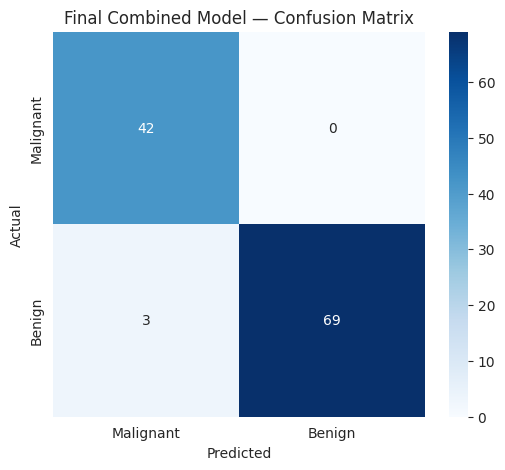

In [ ]:
cm_final = confusion_matrix(
    y_test,
    y_pred_final
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Malignant",
        "Benign"
    ],
    yticklabels=[
        "Malignant",
        "Benign"
    ]
)

plt.title(
    "Final Combined Model — Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
def get_metrics(model):

    probabilities = model.predict(
        X_test_sc,
        verbose=0
    ).ravel()

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    return {
        "Test Accuracy": accuracy_score(
            y_test,
            predictions
        ),

        "Test Precision": precision_score(
            y_test,
            predictions
        ),

        "Test Recall": recall_score(
            y_test,
            predictions
        ),

        "Test F1-Score": f1_score(
            y_test,
            predictions
        )
    }

In [ ]:
results = []

# SLP
metrics = get_metrics(model_slp)

results.append({
    "Model": "SLP",
    "Architecture": "30 → 1",
    "Regularization": "None",
    "Dropout Rate": 0,
    "Early Stopping": "No",
    **metrics
})


# Best MLP
metrics = get_metrics(best_mlp)

results.append({
    "Model": f"MLP-{best_activation}",
    "Architecture": "30 → 64 → 32 → 1",
    "Regularization": "None",
    "Dropout Rate": 0,
    "Early Stopping": "No",
    **metrics
})


# Early Stopping
metrics = get_metrics(model_es)

results.append({
    "Model": "MLP + Early Stopping",
    "Architecture": "30 → 128 → 64 → 1",
    "Regularization": "None",
    "Dropout Rate": 0,
    "Early Stopping": "Yes",
    **metrics
})


# Best Dropout
metrics = get_metrics(best_dropout_model)

results.append({
    "Model": f"MLP + {best_dropout_name}",
    "Architecture": "30 → 128 → 64 → 1",
    "Regularization": "None",
    "Dropout Rate": best_dropout_name.split()[-1],
    "Early Stopping": "Yes",
    **metrics
})


# L2
metrics = get_metrics(model_l2)

results.append({
    "Model": "MLP + L2",
    "Architecture": "30 → 128 → 64 → 1",
    "Regularization": "L2 (0.001)",
    "Dropout Rate": 0,
    "Early Stopping": "Yes",
    **metrics
})


# Final
metrics = get_metrics(model_final)

results.append({
    "Model": "Final Combined Model",
    "Architecture": "30 → 128 → 64 → 1",
    "Regularization": "L2 (0.001)",
    "Dropout Rate": 0.3,
    "Early Stopping": "Yes",
    **metrics
})

In [ ]:
results_df = pd.DataFrame(results)

results_df

,Model,Architecture,Regularization,Dropout Rate,Early Stopping,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,SLP,30 → 1,None,0,No,0.929825,0.984848,0.902778,0.942029
1,MLP-ReLU,30 → 64 → 32 → 1,None,0,No,0.964912,1.000000,0.944444,0.971429
2,MLP + Early Stopping,30 → 128 → 64 → 1,None,0,Yes,0.982456,1.000000,0.972222,0.985915
3,MLP + Dropout 0.1,30 → 128 → 64 → 1,None,0.1,Yes,0.982456,1.000000,0.972222,0.985915
4,MLP + L2,30 → 128 → 64 → 1,L2 (0.001),0,Yes,0.964912,1.000000,0.944444,0.971429
5,Final Combined Model,30 → 128 → 64 → 1,L2 (0.001),0.3,Yes,0.973684,1.000000,0.958333,0.978723


In [ ]:
results_df.style.highlight_max(
    subset=[
        "Test Accuracy",
        "Test F1-Score"
    ],
    color="#ffcccc"
)

,Model,Architecture,Regularization,Dropout Rate,Early Stopping,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,SLP,30 → 1,None,0,No,0.929825,0.984848,0.902778,0.942029
1,MLP-ReLU,30 → 64 → 32 → 1,None,0,No,0.964912,1.000000,0.944444,0.971429
2,MLP + Early Stopping,30 → 128 → 64 → 1,None,0,Yes,0.982456,1.000000,0.972222,0.985915
3,MLP + Dropout 0.1,30 → 128 → 64 → 1,None,0.1,Yes,0.982456,1.000000,0.972222,0.985915
4,MLP + L2,30 → 128 → 64 → 1,L2 (0.001),0,Yes,0.964912,1.000000,0.944444,0.971429
5,Final Combined Model,30 → 128 → 64 → 1,L2 (0.001),0.300000,Yes,0.973684,1.000000,0.958333,0.978723


In [ ]:
results_df.sort_values(
    "Test F1-Score",
    ascending=False
)

,Model,Architecture,Regularization,Dropout Rate,Early Stopping,Test Accuracy,Test Precision,Test Recall,Test F1-Score
3,MLP + Dropout 0.1,30 → 128 → 64 → 1,None,0.1,Yes,0.982456,1.000000,0.972222,0.985915
2,MLP + Early Stopping,30 → 128 → 64 → 1,None,0,Yes,0.982456,1.000000,0.972222,0.985915
5,Final Combined Model,30 → 128 → 64 → 1,L2 (0.001),0.3,Yes,0.973684,1.000000,0.958333,0.978723
1,MLP-ReLU,30 → 64 → 32 → 1,None,0,No,0.964912,1.000000,0.944444,0.971429
4,MLP + L2,30 → 128 → 64 → 1,L2 (0.001),0,Yes,0.964912,1.000000,0.944444,0.971429
0,SLP,30 → 1,None,0,No,0.929825,0.984848,0.902778,0.942029


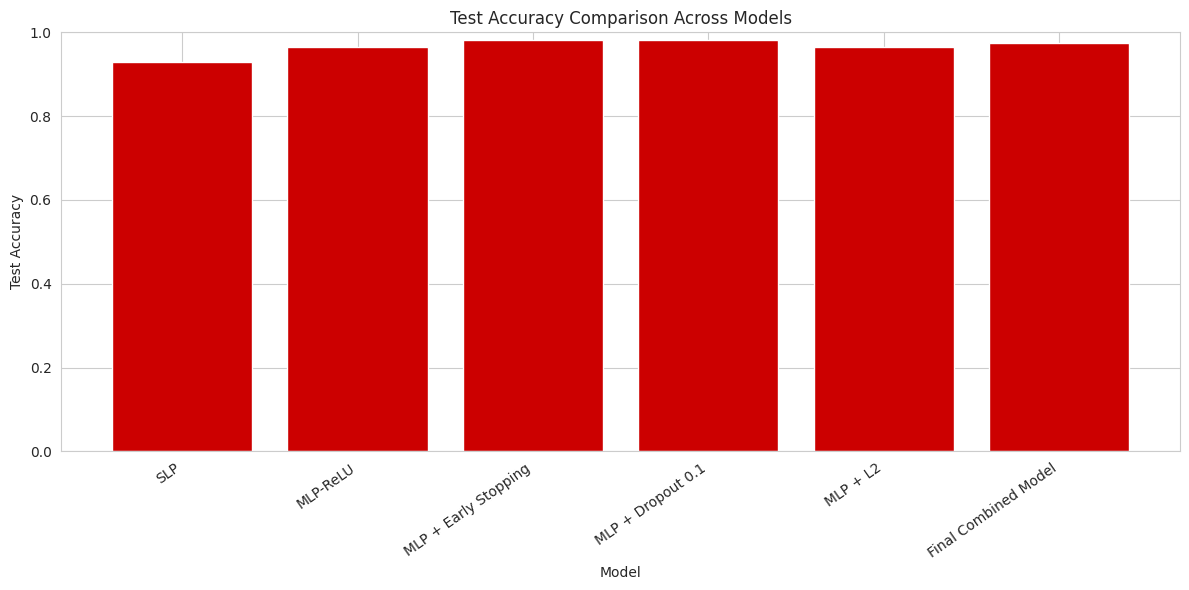

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    results_df["Model"],
    results_df["Test Accuracy"],
    color="#CC0000"
)

plt.title(
    "Test Accuracy Comparison Across Models"
)

plt.xlabel("Model")
plt.ylabel("Test Accuracy")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.ylim(
    0,
    1
)

plt.tight_layout()
plt.show()

In [ ]:
thresholds = [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60
]

threshold_results = []

for threshold in thresholds:

    predictions = (
        y_prob_final >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions
        ),
        "Recall": recall_score(
            y_test,
            predictions
        ),
        "F1": f1_score(
            y_test,
            predictions
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.30,0.982456,0.986111,0.986111,0.986111
1,0.35,0.973684,0.985915,0.972222,0.979021
2,0.40,0.982456,1.000000,0.972222,0.985915
3,0.45,0.982456,1.000000,0.972222,0.985915
4,0.50,0.973684,1.000000,0.958333,0.978723
5,0.55,0.973684,1.000000,0.958333,0.978723
6,0.60,0.973684,1.000000,0.958333,0.978723


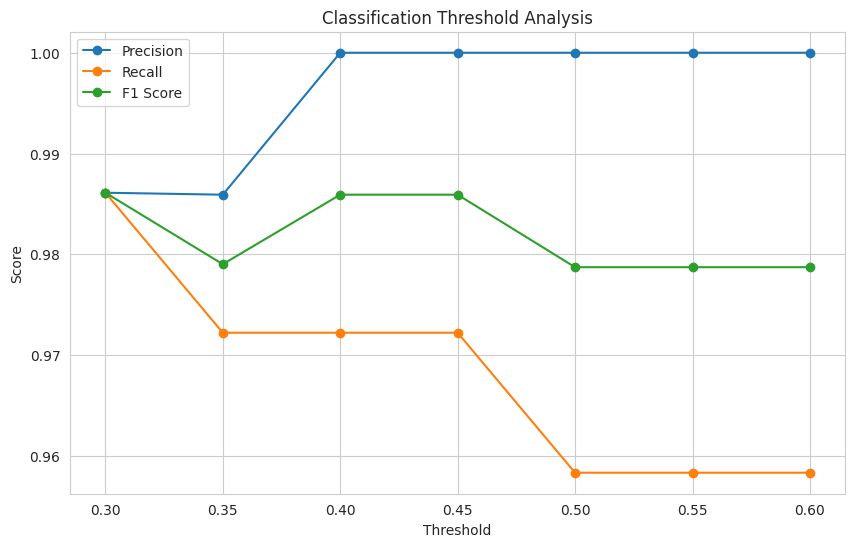

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1 Score"
)

plt.title(
    "Classification Threshold Analysis"
)

plt.xlabel("Threshold")
plt.ylabel("Score")

plt.legend()

plt.show()

In [ ]:
best_accuracy_row = results_df.loc[
    results_df["Test Accuracy"].idxmax()
]

best_recall_row = results_df.loc[
    results_df["Test Recall"].idxmax()
]

best_f1_row = results_df.loc[
    results_df["Test F1-Score"].idxmax()
]

print("Best Accuracy Model:")
print(best_accuracy_row["Model"])

print("\nBest Recall Model:")
print(best_recall_row["Model"])

print("\nBest F1 Model:")
print(best_f1_row["Model"])

Best Accuracy Model:
MLP + Early Stopping

Best Recall Model:
MLP + Early Stopping

Best F1 Model:
MLP + Early Stopping


In [ ]:
os.makedirs("plots", exist_ok=True)

In [ ]:
plt.savefig(
    "plots/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.savefig(
    "plots/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [ ]:
import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Scaler saved successfully.")

Scaler saved successfully.


# Conclusion

This project successfully implemented a complete deep learning workflow for binary breast cancer classification using the Breast Cancer Wisconsin dataset. The project started with exploratory data analysis, where the class distribution and feature correlations were examined. The data was then divided into training and testing sets using stratified sampling, and `StandardScaler` was applied using only the training data to avoid data leakage.

A Single-Layer Perceptron (SLP) was first developed as a baseline model. The SLP provided a simple approach to binary classification but was limited because it could learn only a linear decision boundary. To overcome this limitation, a Multi-Layer Perceptron (MLP) with the architecture `30 → 64 → 32 → 1` was developed and different hidden-layer activation functions—ReLU, Tanh, and Sigmoid—were compared.

The project then investigated several techniques for improving model generalization. Early Stopping was used to stop training when validation loss stopped improving, while Dropout rates of 0.1, 0.3, and 0.5 were compared to reduce overfitting. L1, L2, and combined L1-L2 regularization were also evaluated to understand their effects on model complexity and performance.

Finally, a combined neural network using ReLU activation, L2 regularization, Dropout, and Early Stopping was developed. The models were compared using Accuracy, Precision, Recall, and F1-Score. The comparison demonstrates how different architectural and regularization techniques affect model performance and generalization.

From a medical decision-support perspective, accuracy alone should not be the only consideration. Recall is particularly important because a false negative—incorrectly classifying a malignant case as benign—can have serious consequences. Therefore, the final model should be selected by considering the balance between recall, precision, F1-score, and the clinical cost of classification errors.

Overall, this project demonstrates the complete process of developing, evaluating, comparing, and interpreting neural-network models for binary classification. It also highlights the importance of preprocessing, nonlinear activation functions, Early Stopping, Dropout, and regularization in building models that generalize better to unseen data.
